In [1]:
import warnings
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
warnings.filterwarnings("ignore")

<h1>Load and Prepare Data</h1>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
image = Image.open("/content/drive/MyDrive/AI and ML/workshop1/spidey.png").convert("L")

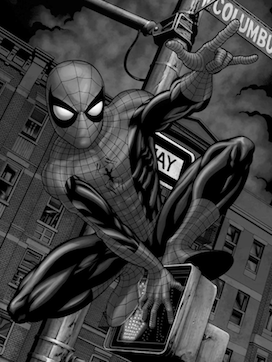

In [7]:
image

In [8]:
image_array = np.array(image)

In [9]:
mean = np.mean(image_array)
std = np.std(image_array)

#standaraization

stan_data = (image_array - mean) / std

In [10]:
np.mean(stan_data)

np.float64(-6.97091609871889e-17)

In [11]:
np.std(stan_data)

np.float64(1.0)

In [12]:
cov_matrix = np.cov(stan_data)

In [13]:
image_array.shape

(362, 272)

In [14]:
cov_matrix.shape

(362, 362)

<h1>Eigen Decomposition and Identifying Principal Components</h1>

In [15]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

In [16]:
eigenvalues

array([ 4.50339490e+01+0.00000000e+00j,  3.86138416e+01+0.00000000e+00j,
        2.53553311e+01+0.00000000e+00j,  2.19224481e+01+0.00000000e+00j,
        1.83456154e+01+0.00000000e+00j,  1.60018780e+01+0.00000000e+00j,
        1.23017360e+01+0.00000000e+00j,  1.15254113e+01+0.00000000e+00j,
        9.40388838e+00+0.00000000e+00j,  8.45792389e+00+0.00000000e+00j,
        8.03876095e+00+0.00000000e+00j,  6.87250493e+00+0.00000000e+00j,
        6.57371378e+00+0.00000000e+00j,  5.74531803e+00+0.00000000e+00j,
        5.45716251e+00+0.00000000e+00j,  5.17071698e+00+0.00000000e+00j,
        4.46003335e+00+0.00000000e+00j,  3.94596462e+00+0.00000000e+00j,
        3.73637100e+00+0.00000000e+00j,  3.71518434e+00+0.00000000e+00j,
        3.46465316e+00+0.00000000e+00j,  3.29895010e+00+0.00000000e+00j,
        2.93492256e+00+0.00000000e+00j,  2.75718004e+00+0.00000000e+00j,
        2.74952554e+00+0.00000000e+00j,  2.39778690e+00+0.00000000e+00j,
        2.38613599e+00+0.00000000e+00j,  2.30063414

In [17]:
eigenvectors

array([[ 0.10913114+0.j,  0.00551108+0.j,  0.03240081+0.j, ...,
         0.01663244+0.j,  0.02280443+0.j,  0.02027568+0.j],
       [ 0.11552544+0.j, -0.00196974+0.j,  0.03347615+0.j, ...,
        -0.03342401+0.j, -0.02843917+0.j, -0.02329274+0.j],
       [ 0.12052108+0.j, -0.00975859+0.j,  0.03653054+0.j, ...,
         0.00263571+0.j,  0.00435105+0.j,  0.00685967+0.j],
       ...,
       [ 0.04235083+0.j, -0.00651827+0.j, -0.07934247+0.j, ...,
         0.03493038+0.j,  0.06072161+0.j,  0.0894962 +0.j],
       [ 0.0418861 +0.j,  0.00223796+0.j, -0.07314751+0.j, ...,
        -0.04051714+0.j, -0.05715648+0.j, -0.06308853+0.j],
       [ 0.03884599+0.j, -0.00319837+0.j, -0.06834938+0.j, ...,
        -0.03799227+0.j, -0.02631646+0.j,  0.0017896 +0.j]])

In [18]:
k = 50

top_k_eigenvectors = sorted_eigenvectors[:, :k]
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

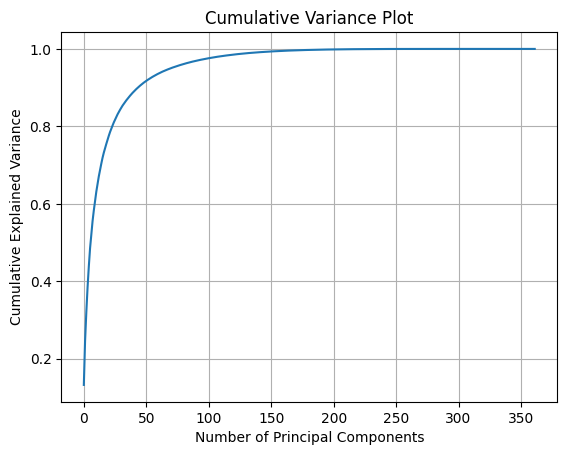

In [19]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.grid()
plt.show()

<h1>Reconstruction and Experiment</h1>

In [20]:
stan_data.shape

(362, 272)

In [21]:
top_k_eigenvectors.shape

(362, 50)

In [22]:
Z = stan_data.T @ top_k_eigenvectors

In [23]:
reconstructed = (Z @ top_k_eigenvectors.T).T

# restore original scale
reconstructed = reconstructed * std + mean

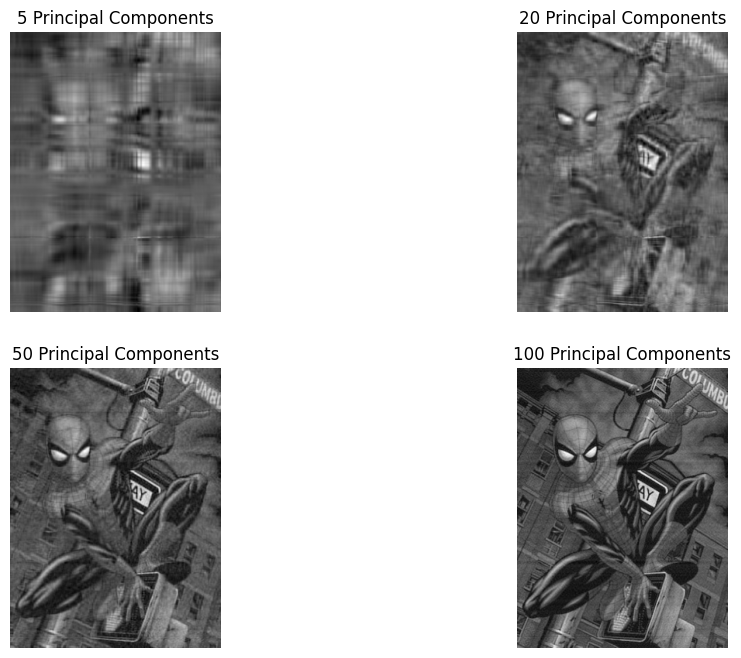

In [24]:
k_values = [5, 20, 50, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):

    W_k = sorted_eigenvectors[:, :k]

    # projection
    Z = stan_data.T @ W_k

    # reconstruction
    reconstructed = Z @ W_k.T
    reconstructed = reconstructed.T

    reconstructed = reconstructed * std + mean

    # remove imaginary part
    reconstructed = np.real(reconstructed)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Principal Components")
    plt.axis("off")

plt.show()

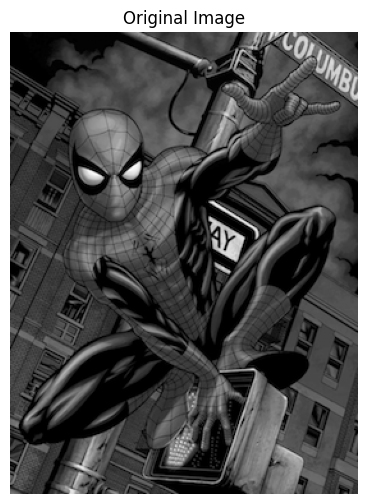

In [25]:
plt.figure(figsize=(6,6))
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()